# Практическое занятие: Градиентный спуск

## Цели практического занятия

- Реализовать различные варианты градиентного спуска
- Исследовать влияние гиперпараметров на сходимость
- Сравнить методы оптимизации на реальных данных
- Применить градиентный спуск к различным задачам машинного обучения

---

## Установка и импорт библиотек

In [5]:
# Основные библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_regression, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, log_loss
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_palette("husl")

print("Библиотеки успешно импортированы!")

Библиотеки успешно импортированы!


## Задание 1: Простейший градиентный спуск

Реализуйте градиентный спуск для минимизации простой квадратичной функции.

### TODO 1.1: Градиентный спуск для функции f(x) = (x-3)² + 5

Реализуйте функцию градиентного спуска для нахождения минимума функции f(x) = (x-3)² + 5

In [6]:
# TODO 1.1: Реализуйте градиентный спуск для функции f(x) = (x-3)² + 5

def objective_function(x):
    """Целевая функция f(x) = (x-3)² + 5"""
    return (x - 3)**2 + 5

def gradient_function(x):
    """Градиент функции f(x) = (x-3)² + 5"""
    return 2 * (x - 3)

def gradient_descent_simple(start_x, learning_rate, num_iterations):
    """
    Простой градиентный спуск
    """
    x = start_x
    history = [x]
    
    for i in range(num_iterations):
        grad = gradient_function(x)       
        x = x - learning_rate * grad      
        history.append(x)                
    
    return x, history

# Тестирование
start_point = 0.0
learning_rate = 0.1
iterations = 50

final_x, x_history = gradient_descent_simple(start_point, learning_rate, iterations)

print(f"Начальная точка: {start_point}")
print(f"Финальная точка: {final_x:.6f}")
print(f"Ожидаемый минимум: x = 3")
print(f"Значение функции в минимуме: {objective_function(final_x):.6f}")

Начальная точка: 0.0
Финальная точка: 2.999957
Ожидаемый минимум: x = 3
Значение функции в минимуме: 5.000000


## Задание 2: Линейная регрессия с градиентным спуском

Реализуйте полную версию градиентного спуска для линейной регрессии.

### TODO 2.1: Batch Gradient Descent для линейной регрессии

Создайте класс для линейной регрессии с использованием градиентного спуска.

In [7]:
# TODO 2.1: Реализуйте Batch Gradient Descent для линейной регрессии

class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, max_iterations=1000, tolerance=1e-6):
        self.learning_rate = learning_rate
        self.max_iterations = max_iterations
        self.tolerance = tolerance
        self.cost_history = []
        self.theta = None
    
    def _add_bias(self, X):
        """Добавляет колонку единиц для свободного члена"""
        return np.c_[np.ones((X.shape[0], 1)), X]  # добавляем столбец 1
    
    def _compute_cost(self, X, y, theta):
        """Вычисляет функцию потерь MSE"""
        m = X.shape[0]
        predictions = X @ theta
        cost = (1 / (2 * m)) * np.sum((predictions - y)**2)
        return cost
    
    def _compute_gradients(self, X, y, theta):
        """Вычисляет градиенты"""
        m = X.shape[0]
        predictions = X @ theta
        gradients = (1 / m) * (X.T @ (predictions - y))
        return gradients
    
    def fit(self, X, y):
        """Обучение модели"""
        X_with_bias = self._add_bias(X)
        m, n = X_with_bias.shape
        
        # Инициализация параметров
        self.theta = np.random.normal(0, 0.01, n)
        
        prev_cost = float('inf')
        
        for i in range(self.max_iterations):
            
            # 1. Функция потерь
            cost = self._compute_cost(X_with_bias, y, self.theta)
            self.cost_history.append(cost)
            
            # 2. Градиенты
            gradients = self._compute_gradients(X_with_bias, y, self.theta)
            
            # 3. Обновление параметров
            self.theta -= self.learning_rate * gradients
            
            # 4. Проверка сходимости
            if abs(prev_cost - cost) < self.tolerance:
                print(f"Сошлось на итерации {i}")
                break
            
            prev_cost = cost
        
        print(f"Обучение завершено за {len(self.cost_history)} итераций")
    
    def predict(self, X):
        """Делает предсказания"""
        X_with_bias = self._add_bias(X)
        return X_with_bias @ self.theta


# Создание данных для тестирования
np.random.seed(42)
X, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)

# Стандартизация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Тестирование
model = LinearRegressionGD(learning_rate=0.1, max_iterations=1000)
model.fit(X_scaled, y)

# Сравнение с sklearn
sk_model = LinearRegression()
sk_model.fit(X_scaled, y)

print("Мои θ:", model.theta)
print("sklearn θ:", np.r_[sk_model.intercept_, sk_model.coef_])

Сошлось на итерации 91
Обучение завершено за 92 итераций
Мои θ: [-3.44931687 40.15166791]
sklearn θ: [-3.44953003 40.15414565]


### TODO 2.2: Визуализация процесса обучения

Создайте визуализацию процесса обучения и сравните с sklearn.

Результаты сравнения:
MSE (ваша реализация): 78.0543
MSE (sklearn): 78.0543


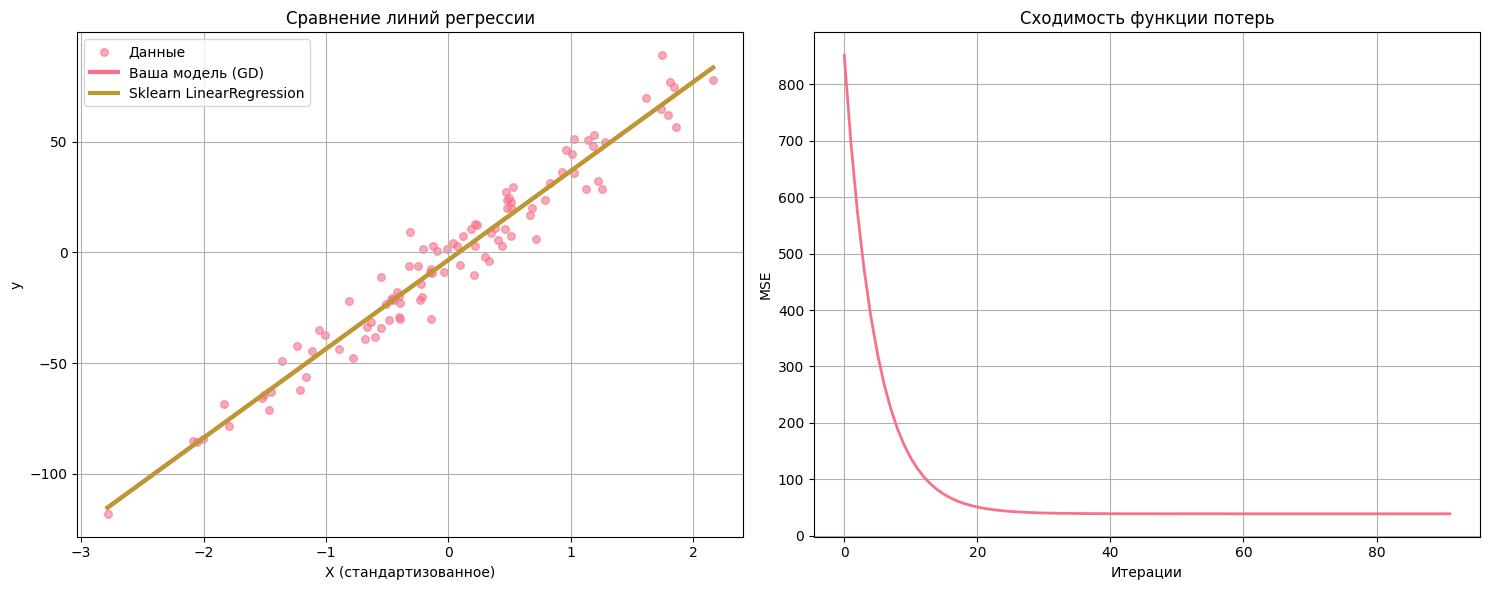

In [10]:
# Создаём модель sklearn для сравнения
sklearn_model = LinearRegression()
sklearn_model.fit(X_scaled, y)

# Предсказания
predictions = model.predict(X_scaled)
sklearn_predictions = sklearn_model.predict(X_scaled)

print("Результаты сравнения:")
print(f"MSE (ваша реализация): {mean_squared_error(y, predictions):.4f}")
print(f"MSE (sklearn): {mean_squared_error(y, sklearn_predictions):.4f}")

# --- ВИЗУАЛИЗАЦИЯ ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# График 1: данные и линии регрессии
ax1.scatter(X_scaled, y, alpha=0.6, label="Данные", s=30)

sorted_idx = np.argsort(X_scaled[:, 0])

ax1.plot(X_scaled[sorted_idx], predictions[sorted_idx],
         label="Ваша модель (GD)", linewidth=3)

ax1.plot(X_scaled[sorted_idx], sklearn_predictions[sorted_idx],
         label="Sklearn LinearRegression", linewidth=3)

ax1.set_title("Сравнение линий регрессии")
ax1.set_xlabel("X (стандартизованное)")
ax1.set_ylabel("y")
ax1.legend()
ax1.grid(True)

# График 2: сходимость функции потерь
ax2.plot(model.cost_history, linewidth=2)
ax2.set_title("Сходимость функции потерь")
ax2.set_xlabel("Итерации")
ax2.set_ylabel("MSE")
ax2.grid(True)

plt.tight_layout()
plt.show()

## Задание 3: Сравнение типов градиентного спуска

Реализуйте и сравните Batch, Stochastic и Mini-batch градиентный спуск.

### TODO 3.1: Stochastic Gradient Descent

Реализуйте стохастический градиентный спуск.

In [13]:
# TODO 3.1: Реализуйте Stochastic Gradient Descent

class LinearRegressionSGD:
    def __init__(self, learning_rate=0.01, max_iterations=1000):
        self.learning_rate = learning_rate
        self.max_iterations = max_iterations
        self.cost_history = []
        self.theta = None
    
    def fit(self, X, y):
        """Обучение с использованием SGD"""
        
        m, n = X.shape
        X_with_bias = np.column_stack([np.ones(m), X])  # добавили bias
        
        # Инициализация параметров θ
        self.theta = np.random.normal(0, 0.01, n + 1)
        
        for epoch in range(self.max_iterations):
            
            # 1. Перемешивание данных
            indices = np.random.permutation(m)
            X_shuffled = X_with_bias[indices]
            y_shuffled = y[indices]
            
            # 2. Проход по каждому примеру
            for i in range(m):
                xi = X_shuffled[i]        # (1 × n)
                yi = y_shuffled[i]
                
                prediction = xi @ self.theta
                error = prediction - yi
                
                # Градиент для одного примера
                gradient = error * xi
                
                # Обновление параметров
                self.theta -= self.learning_rate * gradient
            
            # 3. Функция потерь за эпоху
            predictions = X_with_bias @ self.theta
            cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
            self.cost_history.append(cost)
        
        print(f"SGD обучение завершено за {self.max_iterations} эпох.")
    
    def predict(self, X):
        """Предсказания"""
        m = X.shape[0]
        X_with_bias = np.column_stack([np.ones(m), X])
        return X_with_bias @ self.theta
    
    

### TODO 3.2: Mini-batch Gradient Descent

Реализуйте мини-пакетный градиентный спуск.

In [15]:
class LinearRegressionMiniBatch:
    def __init__(self, learning_rate=0.01, max_iterations=100, batch_size=32):
        self.learning_rate = learning_rate
        self.max_iterations = max_iterations
        self.batch_size = batch_size
        self.cost_history = []
        self.theta = None
    
    def fit(self, X, y):
        """Обучение с использованием Mini-batch GD"""
        m, n = X.shape
        X_with_bias = np.column_stack([np.ones(m), X])
        
        # Инициализация параметров
        self.theta = np.random.normal(0, 0.01, n + 1)
        
        for epoch in range(self.max_iterations):
            
            # 1. Перемешиваем данные
            indices = np.random.permutation(m)
            X_shuffled = X_with_bias[indices]
            y_shuffled = y[indices]
            
            # 2. Проход по мини-пакетам
            for start in range(0, m, self.batch_size):
                end = start + self.batch_size
                X_batch = X_shuffled[start:end]
                y_batch = y_shuffled[start:end]
                
                # Предсказания
                predictions = X_batch @ self.theta
                errors = predictions - y_batch
                
                # 3. Градиент (усреднённый по batch)
                gradient = (1 / len(X_batch)) * (X_batch.T @ errors)
                
                # Обновление параметров
                self.theta -= self.learning_rate * gradient
            
            # 4. Функция потерь за эпоху
            full_predictions = X_with_bias @ self.theta
            cost = (1 / (2 * m)) * np.sum((full_predictions - y) ** 2)
            self.cost_history.append(cost)
        
        print(f"Mini-batch GD завершён за {self.max_iterations} эпох.")
    
    def predict(self, X):
        """Предсказания"""
        m = X.shape[0]
        X_with_bias = np.column_stack([np.ones(m), X])
        return X_with_bias @ self.theta

### TODO 3.3: Сравнение всех методов

Сравните производительность всех трех методов.

Сравнение методов градиентного спуска:
------------------------------------------------------------
Batch GD        | MSE = 0.1606 | Time = 0.0010 сек
SGD             | MSE = 0.0109 | Time = 0.0764 сек
Mini-batch GD   | MSE = 0.0107 | Time = 0.0176 сек
------------------------------------------------------------


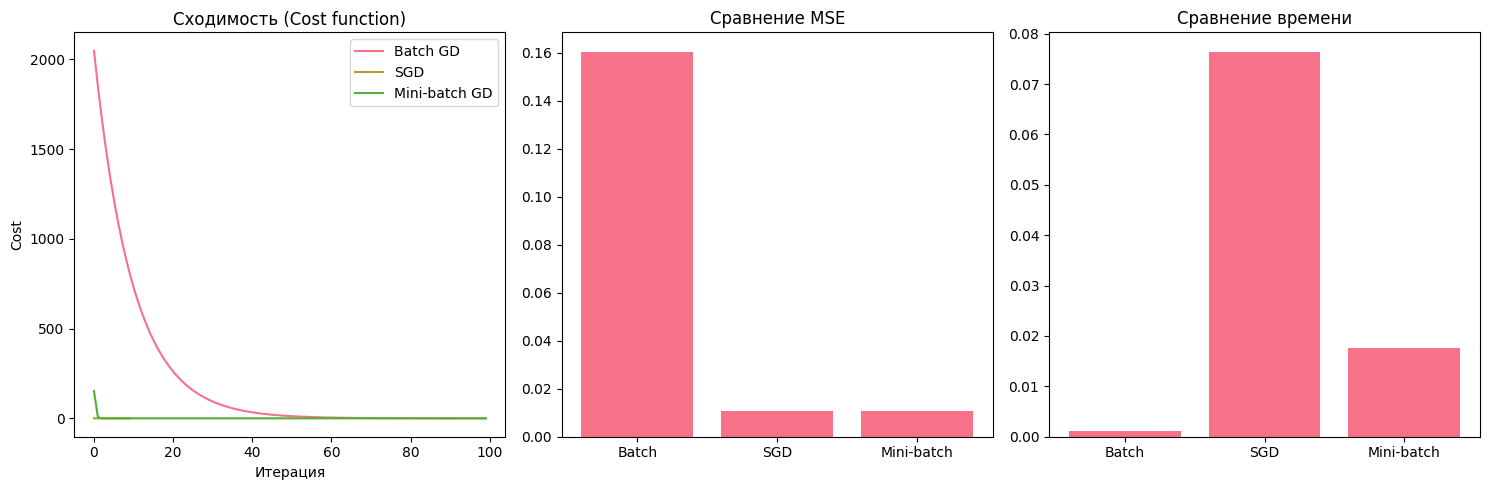

In [19]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import time

# ---------------------------------------------------------
# 1. Batch Gradient Descent
# ---------------------------------------------------------
class LinearRegressionBatchGD:
    def __init__(self, learning_rate=0.01, max_iterations=100):
        self.learning_rate = learning_rate
        self.max_iterations = max_iterations
        self.cost_history = []
        self.theta = None

    def fit(self, X, y):
        m, n = X.shape
        X_b = np.column_stack([np.ones(m), X])
        self.theta = np.random.randn(n + 1)

        for i in range(self.max_iterations):
            predictions = X_b.dot(self.theta)
            errors = predictions - y
            gradient = (1 / m) * X_b.T.dot(errors)
            self.theta -= self.learning_rate * gradient
            cost = (1 / (2 * m)) * np.sum(errors ** 2)
            self.cost_history.append(cost)

    def predict(self, X):
        m = X.shape[0]
        X_b = np.column_stack([np.ones(m), X])
        return X_b.dot(self.theta)

# ---------------------------------------------------------
# 2. SGD
# ---------------------------------------------------------
class LinearRegressionSGD:
    def __init__(self, learning_rate=0.01, max_iterations=100):
        self.learning_rate = learning_rate
        self.max_iterations = max_iterations
        self.cost_history = []
        self.theta = None

    def fit(self, X, y):
        m, n = X.shape
        X_b = np.column_stack([np.ones(m), X])
        self.theta = np.random.randn(n + 1)

        for iter in range(self.max_iterations):
            for i in range(m):
                random_index = np.random.randint(m)
                xi = X_b[random_index:random_index+1]
                yi = y[random_index]
                prediction = xi.dot(self.theta)
                error = prediction - yi
                gradient = xi.T.dot(error)
                self.theta -= self.learning_rate * gradient
            # Cost (приближённо)
            predictions = X_b.dot(self.theta)
            self.cost_history.append(mean_squared_error(y, predictions))

    def predict(self, X):
        m = X.shape[0]
        X_b = np.column_stack([np.ones(m), X])
        return X_b.dot(self.theta)

# ---------------------------------------------------------
# 3. Mini-Batch Gradient Descent
# ---------------------------------------------------------
class LinearRegressionMiniBatch:
    def __init__(self, learning_rate=0.01, max_iterations=100, batch_size=32):
        self.learning_rate = learning_rate
        self.max_iterations = max_iterations
        self.batch_size = batch_size
        self.cost_history = []
        self.theta = None

    def fit(self, X, y):
        m, n = X.shape
        X_b = np.column_stack([np.ones(m), X])
        self.theta = np.random.randn(n + 1)

        for iteration in range(self.max_iterations):
            indices = np.random.permutation(m)
            X_shuffled = X_b[indices]
            y_shuffled = y[indices]

            for start in range(0, m, self.batch_size):
                end = start + self.batch_size
                xb = X_shuffled[start:end]
                yb = y_shuffled[start:end]

                predictions = xb.dot(self.theta)
                errors = predictions - yb
                gradient = (1 / len(xb)) * xb.T.dot(errors)
                self.theta -= self.learning_rate * gradient

            predictions_all = X_b.dot(self.theta)
            cost = mean_squared_error(y, predictions_all)
            self.cost_history.append(cost)

    def predict(self, X):
        m = X.shape[0]
        X_b = np.column_stack([np.ones(m), X])
        return X_b.dot(self.theta)

# ======================================================================
# ======================= СРАВНЕНИЕ МЕТОДОВ =============================
# ======================================================================

np.random.seed(42)
X_large, y_large = make_regression(
    n_samples=1000,
    n_features=5,
    noise=0.1,
    random_state=42
)

X_large_scaled = StandardScaler().fit_transform(X_large)

results = {}

# ---------------- Batch GD ----------------
start = time.time()
batch = LinearRegressionBatchGD(learning_rate=0.05, max_iterations=100)
batch.fit(X_large_scaled, y_large)
batch_time = time.time() - start
batch_pred = batch.predict(X_large_scaled)
batch_mse = mean_squared_error(y_large, batch_pred)

results["Batch GD"] = (batch_mse, batch_time, batch.cost_history)

# ---------------- SGD ---------------------
start = time.time()
sgd = LinearRegressionSGD(learning_rate=0.01, max_iterations=10)
sgd.fit(X_large_scaled, y_large)
sgd_time = time.time() - start
sgd_pred = sgd.predict(X_large_scaled)
sgd_mse = mean_squared_error(y_large, sgd_pred)

results["SGD"] = (sgd_mse, sgd_time, sgd.cost_history)

# ---------------- Mini-Batch GD ----------------
start = time.time()
mb = LinearRegressionMiniBatch(learning_rate=0.05, max_iterations=100, batch_size=32)
mb.fit(X_large_scaled, y_large)
mb_time = time.time() - start
mb_pred = mb.predict(X_large_scaled)
mb_mse = mean_squared_error(y_large, mb_pred)

results["Mini-batch GD"] = (mb_mse, mb_time, mb.cost_history)

# ======================================================================
# =========================== ВЫВОД ====================================
# ======================================================================

print("Сравнение методов градиентного спуска:")
print("-" * 60)
for name, (mse, t, _) in results.items():
    print(f"{name:15} | MSE = {mse:.4f} | Time = {t:.4f} сек")
print("-" * 60)

# ======================================================================
# =========================== ГРАФИКИ ==================================
# ======================================================================

plt.figure(figsize=(15, 5))

# ---- Сходимость ----
plt.subplot(1, 3, 1)
plt.plot(results["Batch GD"][2], label="Batch GD")
plt.plot(results["SGD"][2], label="SGD")
plt.plot(results["Mini-batch GD"][2], label="Mini-batch GD")
plt.title("Сходимость (Cost function)")
plt.xlabel("Итерация")
plt.ylabel("Cost")
plt.legend()

# ---- MSE ----
plt.subplot(1, 3, 2)
plt.bar(["Batch", "SGD", "Mini-batch"],
        [results["Batch GD"][0], results["SGD"][0], results["Mini-batch GD"][0]])
plt.title("Сравнение MSE")

# ---- Время ----
plt.subplot(1, 3, 3)
plt.bar(["Batch", "SGD", "Mini-batch"],
        [results["Batch GD"][1], results["SGD"][1], results["Mini-batch GD"][1]])
plt.title("Сравнение времени")

plt.tight_layout()
plt.show()

## Задание 4: Исследование Learning Rate

Исследуйте влияние различных значений learning rate на сходимость.

### TODO 4.1: Тестирование различных Learning Rate

Протестируйте разные значения learning rate и проанализируйте результаты.

Результаты тестирования learning rate:
------------------------------------------------------------
Learning Rate   Сходимость   Итерации   Финальная MSE  
------------------------------------------------------------
0.001           True         200        1177.9912      
0.01            True         200        106.6619       
0.1             False        200        78.0543        
0.5             False        200        78.0543        
1.0             True         200        78.0543        
1.5             False        200        78.0543        
------------------------------------------------------------


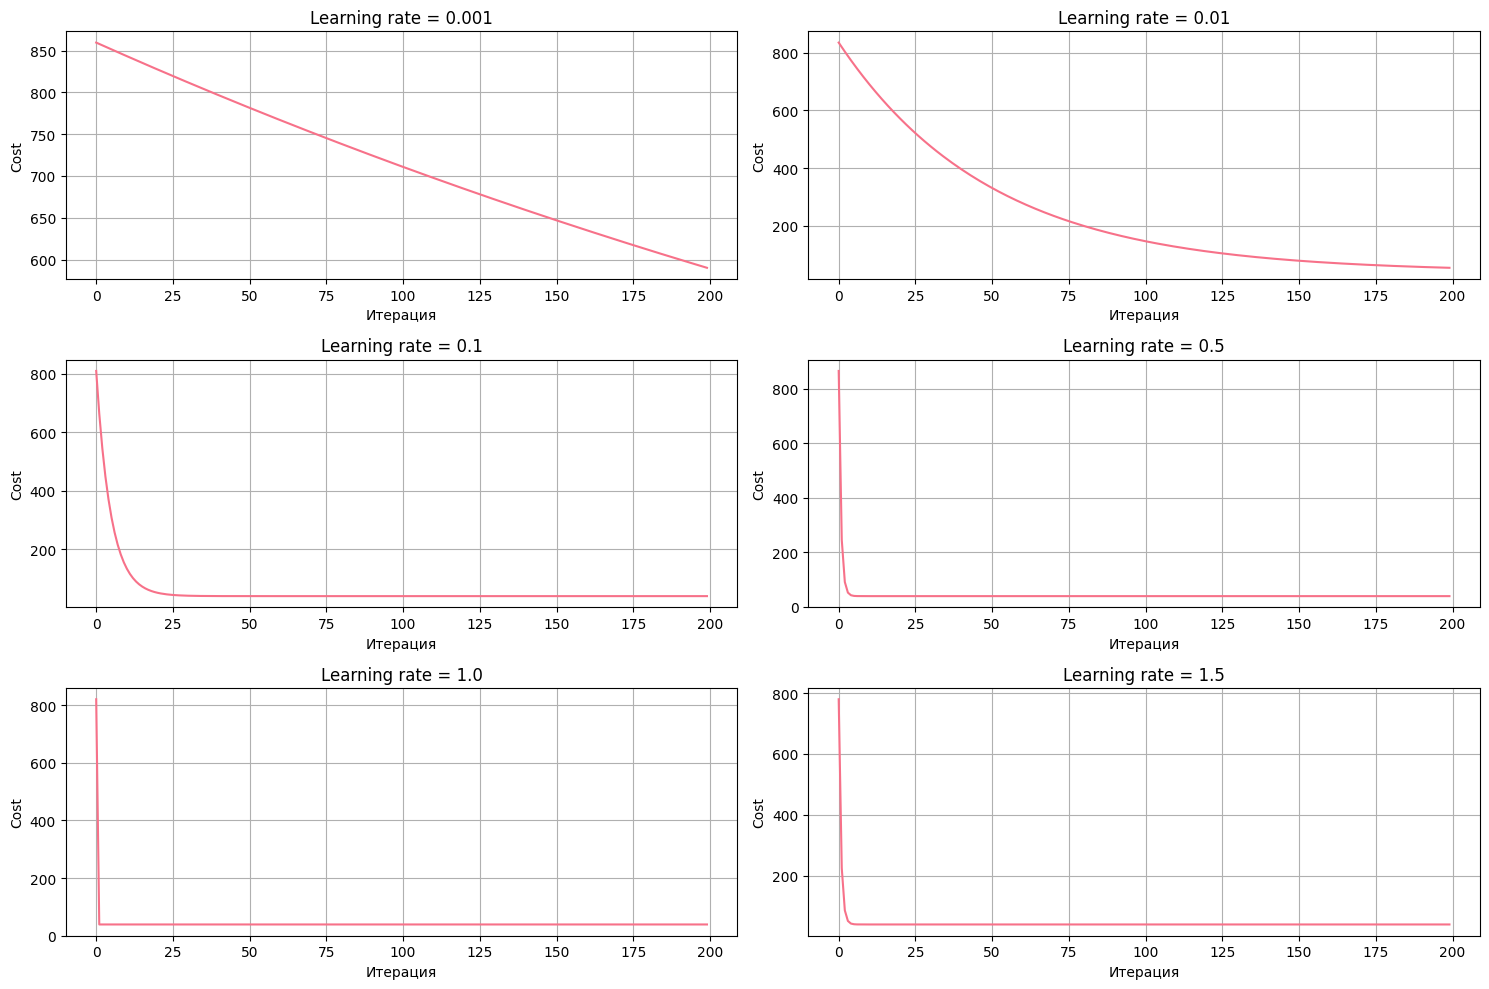

In [20]:
# TODO 4.1: Исследование влияния learning rate

def test_learning_rates(X, y, learning_rates, max_iterations=200):
    """
    Тестирует различные learning rates
    
    Returns:
    results: dict
        {
            lr_value: {
                "cost_history": [...],
                "final_mse": float,
                "iterations": int,
                "converged": bool
            }
        }
    """
    results = {}
    
    for lr in learning_rates:
        model = LinearRegressionBatchGD(
            learning_rate=lr,
            max_iterations=max_iterations
        )
        
        model.fit(X, y)
        predictions = model.predict(X)
        final_mse = mean_squared_error(y, predictions)
        
        # проверка сходимости — если cost не начинает расти
        cost = model.cost_history
        converged = not any(
            cost[i] < cost[i+1] and (i > 5)
            for i in range(len(cost)-1)
        )
        
        results[lr] = {
            "cost_history": cost,
            "final_mse": final_mse,
            "iterations": len(cost),
            "converged": converged
        }
    
    return results


# Тестируемые learning rates
learning_rates = [0.001, 0.01, 0.1, 0.5, 1.0, 1.5]

# Запуск тестирования
results = test_learning_rates(X_scaled, y, learning_rates)

# Анализ результатов
print("Результаты тестирования learning rate:")
print("-" * 60)
print(f"{'Learning Rate':<15} {'Сходимость':<12} {'Итерации':<10} {'Финальная MSE':<15}")
print("-" * 60)

for lr, res in results.items():
    print(f"{lr:<15} {str(res['converged']):<12} {res['iterations']:<10} {res['final_mse']:<15.4f}")

print("-" * 60)

# ------------------- ВИЗУАЛИЗАЦИЯ -------------------

plt.figure(figsize=(15, 10))

for i, lr in enumerate(learning_rates, 1):
    plt.subplot(3, 2, i)
    plt.plot(results[lr]["cost_history"])
    plt.title(f"Learning rate = {lr}")
    plt.xlabel("Итерация")
    plt.ylabel("Cost")
    plt.grid(True)

plt.tight_layout()
plt.show()

### TODO 4.2: Поиск оптимального Learning Rate

Реализуйте простой алгоритм поиска оптимального learning rate.

Оптимальный learning rate: 0.180446
Лучшая MSE: 78.054250


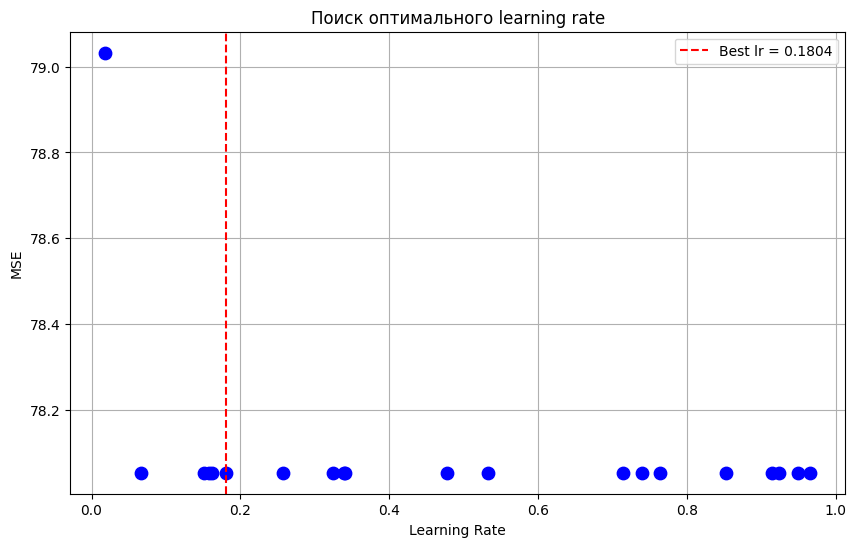

In [21]:
import random

def find_optimal_learning_rate(X, y, lr_min=0.001, lr_max=1.0, num_trials=20):
    """
    Находит оптимальный learning rate методом случайного поиска
    """
    best_lr = None
    best_mse = float('inf')
    results = []
    
    for i in range(num_trials):
        lr = random.uniform(lr_min, lr_max)
        
        model = LinearRegressionBatchGD(learning_rate=lr, max_iterations=200)
        model.fit(X, y)
        predictions = model.predict(X)
        mse = mean_squared_error(y, predictions)
        
        results.append((lr, mse))
        
        if mse < best_mse:
            best_mse = mse
            best_lr = lr
    
    return best_lr, best_mse, results

# ------------------ Поиск оптимального learning rate ------------------
best_lr, best_mse, lr_results = find_optimal_learning_rate(X_scaled, y)

print(f"Оптимальный learning rate: {best_lr:.6f}")
print(f"Лучшая MSE: {best_mse:.6f}")

# ------------------ Визуализация результатов ------------------
lrs = [r[0] for r in lr_results]
mses = [r[1] for r in lr_results]

plt.figure(figsize=(10, 6))
plt.scatter(lrs, mses, color='blue', s=80)
plt.axvline(best_lr, color='red', linestyle='--', label=f'Best lr = {best_lr:.4f}')
plt.title("Поиск оптимального learning rate")
plt.xlabel("Learning Rate")
plt.ylabel("MSE")
plt.grid(True)
plt.legend()
plt.show()

## Задание 5: Логистическая регрессия с градиентным спуском

Примените градиентный спуск к задаче классификации.

### TODO 5.1: Реализация логистической регрессии

Реализуйте логистическую регрессию с использованием градиентного спуска.

In [22]:
class LogisticRegressionGD:
    def __init__(self, learning_rate=0.01, max_iterations=1000, tolerance=1e-6):
        self.learning_rate = learning_rate
        self.max_iterations = max_iterations
        self.tolerance = tolerance
        self.cost_history = []
        self.theta = None
    
    def sigmoid(self, z):
        """Сигмоидная функция с защитой от переполнения"""
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    def _compute_cost(self, X, y, theta):
        """Логистическая функция потерь"""
        m = X.shape[0]
        h = self.sigmoid(X.dot(theta))
        epsilon = 1e-15  # защита от log(0)
        cost = -(1/m) * np.sum(y * np.log(h + epsilon) + (1 - y) * np.log(1 - h + epsilon))
        return cost
    
    def fit(self, X, y):
        """Обучение модели"""
        m, n = X.shape
        X_b = np.column_stack([np.ones(m), X])
        self.theta = np.random.normal(0, 0.01, n + 1)
        
        prev_cost = float('inf')
        
        for i in range(self.max_iterations):
            h = self.sigmoid(X_b.dot(self.theta))
            cost = self._compute_cost(X_b, y, self.theta)
            self.cost_history.append(cost)
            
            gradient = (1 / m) * X_b.T.dot(h - y)
            self.theta -= self.learning_rate * gradient
            
            # Проверка сходимости
            if abs(prev_cost - cost) < self.tolerance:
                print(f"Сходимость достигнута на итерации {i}")
                break
            prev_cost = cost
    
    def predict_proba(self, X):
        """Предсказание вероятностей"""
        m = X.shape[0]
        X_b = np.column_stack([np.ones(m), X])
        return self.sigmoid(X_b.dot(self.theta))
    
    def predict(self, X):
        """Предсказание классов"""
        probs = self.predict_proba(X)
        return (probs >= 0.5).astype(int)

### TODO 5.2: Сравнение с sklearn и визуализация

Сравните вашу реализацию с sklearn и создайте визуализацию.

Сравнение логистической регрессии:
Accuracy (ваша реализация): 0.9010
Accuracy (sklearn): 0.9030


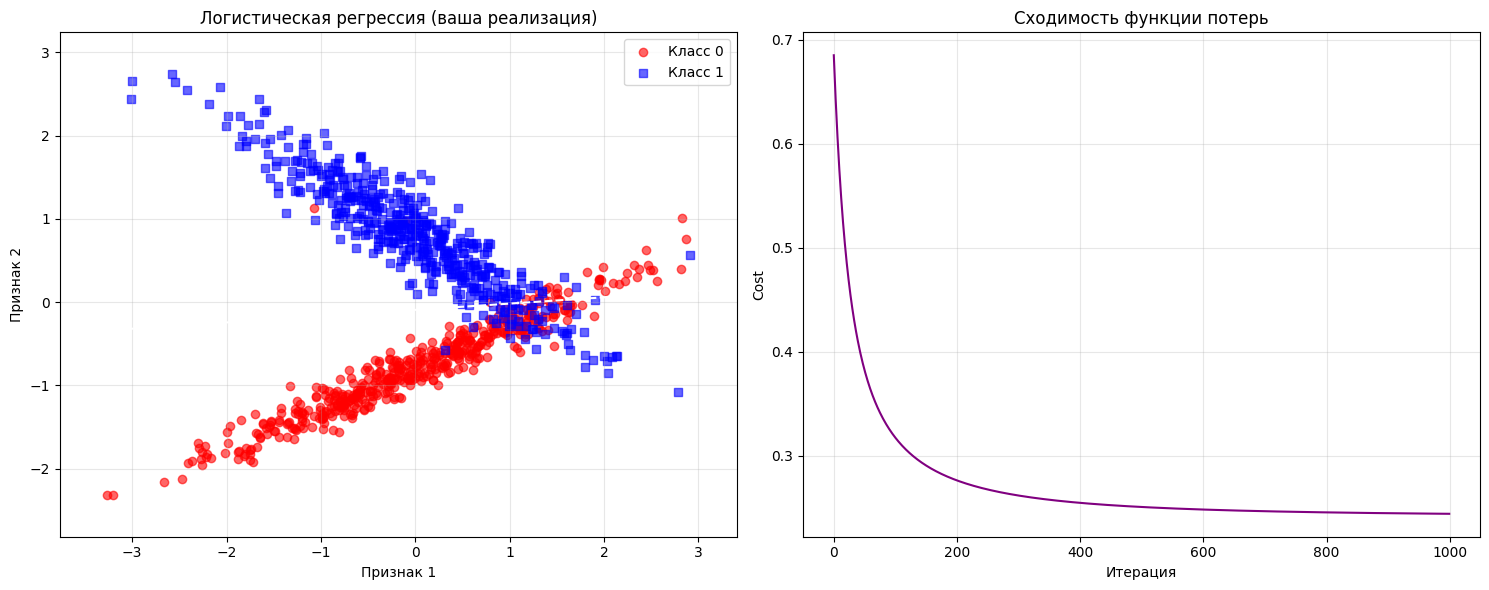

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ---------------- Создание данных ----------------
X_class, y_class = make_classification(
    n_samples=1000, n_features=2, n_redundant=0, 
    n_informative=2, n_clusters_per_class=1, random_state=42
)

# ---------------- Стандартизация ----------------
scaler_class = StandardScaler()
X_class_scaled = scaler_class.fit_transform(X_class)

# ---------------- Ваша реализация Logistic Regression ----------------
class LogisticRegressionGD:
    def __init__(self, learning_rate=0.1, max_iterations=1000, tolerance=1e-6):
        self.learning_rate = learning_rate
        self.max_iterations = max_iterations
        self.tolerance = tolerance
        self.cost_history = []
        self.theta = None
    
    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    def _compute_cost(self, X, y, theta):
        m = X.shape[0]
        h = self.sigmoid(X.dot(theta))
        epsilon = 1e-15
        cost = -(1/m) * np.sum(y * np.log(h + epsilon) + (1 - y) * np.log(1 - h + epsilon))
        return cost
    
    def fit(self, X, y):
        m, n = X.shape
        X_b = np.column_stack([np.ones(m), X])
        self.theta = np.random.normal(0, 0.01, n + 1)
        prev_cost = float('inf')
        
        for i in range(self.max_iterations):
            h = self.sigmoid(X_b.dot(self.theta))
            cost = self._compute_cost(X_b, y, self.theta)
            self.cost_history.append(cost)
            gradient = (1 / m) * X_b.T.dot(h - y)
            self.theta -= self.learning_rate * gradient
            if abs(prev_cost - cost) < self.tolerance:
                break
            prev_cost = cost
    
    def predict_proba(self, X):
        m = X.shape[0]
        X_b = np.column_stack([np.ones(m), X])
        return self.sigmoid(X_b.dot(self.theta))
    
    def predict(self, X):
        probs = self.predict_proba(X)
        return (probs >= 0.5).astype(int)

# ---------------- Обучение моделей ----------------
log_model = LogisticRegressionGD(learning_rate=0.1, max_iterations=1000)
log_model.fit(X_class_scaled, y_class)

sklearn_log = LogisticRegression(max_iter=1000)
sklearn_log.fit(X_class_scaled, y_class)

# ---------------- Предсказания ----------------
your_predictions = log_model.predict(X_class_scaled)
sklearn_predictions = sklearn_log.predict(X_class_scaled)

print("Сравнение логистической регрессии:")
print(f"Accuracy (ваша реализация): {accuracy_score(y_class, your_predictions):.4f}")
print(f"Accuracy (sklearn): {accuracy_score(y_class, sklearn_predictions):.4f}")

# ---------------- Визуализация ----------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- График 1: Данные и граница решения ---
ax1.scatter(X_class_scaled[y_class==0, 0], X_class_scaled[y_class==0, 1], 
           c='red', marker='o', alpha=0.6, label='Класс 0')
ax1.scatter(X_class_scaled[y_class==1, 0], X_class_scaled[y_class==1, 1], 
           c='blue', marker='s', alpha=0.6, label='Класс 1')

x_min, x_max = X_class_scaled[:, 0].min() - 0.5, X_class_scaled[:, 0].max() + 0.5
y_min, y_max = X_class_scaled[:, 1].min() - 0.5, X_class_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

grid = np.c_[xx.ravel(), yy.ravel()]
probs = log_model.predict_proba(grid).reshape(-1)
probs = probs.reshape(xx.shape)

ax1.contour(xx, yy, probs, levels=[0.5], cmap="Greys", linestyles='--')
ax1.set_xlabel('Признак 1')
ax1.set_ylabel('Признак 2')
ax1.set_title('Логистическая регрессия (ваша реализация)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- График 2: Сходимость функции потерь ---
ax2.plot(log_model.cost_history, color='purple')
ax2.set_xlabel('Итерация')
ax2.set_ylabel('Cost')
ax2.set_title('Сходимость функции потерь')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Задание 6: Продвинутые методы оптимизации

Реализуйте и сравните различные методы оптимизации.

### TODO 6.1: Gradient Descent с Momentum

Реализуйте градиентный спуск с импульсом.

Финальное MSE (Momentum): 101.6312


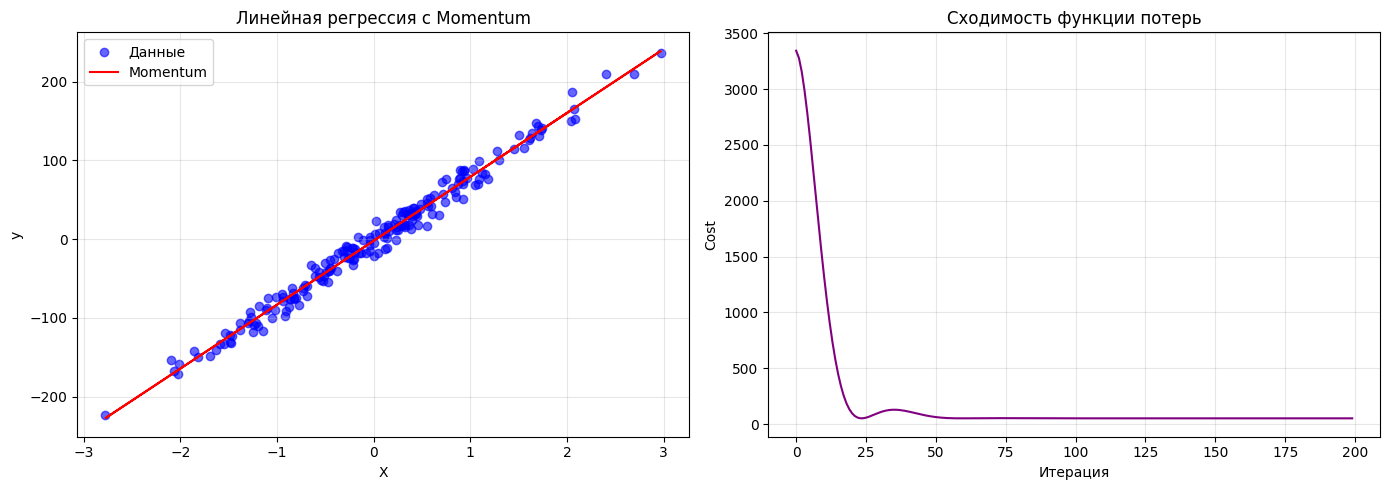

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# ---------------- Создание данных ----------------
np.random.seed(42)
X, y = make_regression(n_samples=200, n_features=1, noise=10, random_state=42)

# Стандартизация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------- Реализация Linear Regression с Momentum ----------------
class LinearRegressionMomentum:
    def __init__(self, learning_rate=0.01, momentum=0.9, max_iterations=1000):
        self.learning_rate = learning_rate
        self.momentum = momentum
        self.max_iterations = max_iterations
        self.cost_history = []
        self.theta = None
    
    def fit(self, X, y):
        m, n = X.shape
        X_b = np.column_stack([np.ones(m), X])
        self.theta = np.random.normal(0, 0.01, n + 1)
        velocity = np.zeros_like(self.theta)
        
        for i in range(self.max_iterations):
            # Предсказания
            y_pred = X_b.dot(self.theta)
            # Функция потерь
            cost = (1/(2*m)) * np.sum((y_pred - y)**2)
            self.cost_history.append(cost)
            # Градиенты
            gradient = (1/m) * X_b.T.dot(y_pred - y)
            # Обновление velocity
            velocity = self.momentum * velocity + (1 - self.momentum) * gradient
            # Обновление параметров
            self.theta -= self.learning_rate * velocity
    
    def predict(self, X):
        m = X.shape[0]
        X_b = np.column_stack([np.ones(m), X])
        return X_b.dot(self.theta)

# ---------------- Тестирование ----------------
momentum_model = LinearRegressionMomentum(learning_rate=0.1, momentum=0.9, max_iterations=200)
momentum_model.fit(X_scaled, y)
predictions = momentum_model.predict(X_scaled)

# MSE
mse = mean_squared_error(y, predictions)
print(f"Финальное MSE (Momentum): {mse:.4f}")

# ---------------- Визуализация ----------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

# График данных и линии регрессии
ax1.scatter(X_scaled, y, color='blue', alpha=0.6, label='Данные')
ax1.plot(X_scaled, predictions, color='red', label='Momentum')
ax1.set_xlabel('X')
ax1.set_ylabel('y')
ax1.set_title('Линейная регрессия с Momentum')
ax1.legend()
ax1.grid(True, alpha=0.3)

# График сходимости функции потерь
ax2.plot(momentum_model.cost_history, color='purple')
ax2.set_xlabel('Итерация')
ax2.set_ylabel('Cost')
ax2.set_title('Сходимость функции потерь')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### TODO 6.2: Сравнение методов оптимизации

Сравните обычный GD, GD с momentum и другие методы.

Сравнение методов оптимизации:
------------------------------------------------------------
GD         Final MSE: 0.345732
Momentum   Final MSE: 0.355108
High LR    Final MSE: 0.010108


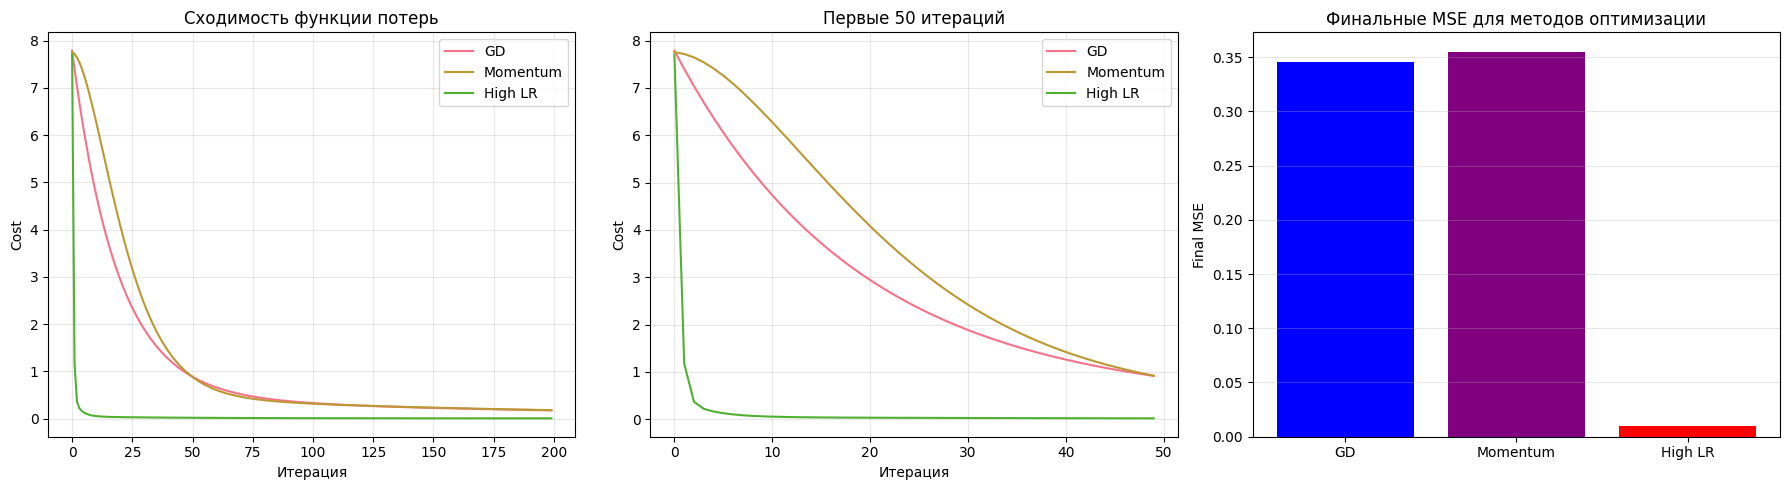

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# ---------------- Создание сложного датасета ----------------
np.random.seed(42)
X_complex = np.random.randn(300, 3)
X_complex[:, 1] = X_complex[:, 0] + 0.5 * np.random.randn(300)
X_complex[:, 2] = X_complex[:, 0] - 0.3 * X_complex[:, 1] + 0.2 * np.random.randn(300)
y_complex = 3 * X_complex[:, 0] + 2 * X_complex[:, 1] - X_complex[:, 2] + np.random.randn(300) * 0.1

# Стандартизация
scaler = StandardScaler()
X_complex_scaled = scaler.fit_transform(X_complex)

# ---------------- Реализация обычного Batch GD ----------------
class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, max_iterations=200):
        self.learning_rate = learning_rate
        self.max_iterations = max_iterations
        self.cost_history = []
        self.theta = None
    
    def fit(self, X, y):
        m, n = X.shape
        X_b = np.column_stack([np.ones(m), X])
        self.theta = np.random.normal(0, 0.01, n + 1)
        
        for i in range(self.max_iterations):
            y_pred = X_b.dot(self.theta)
            cost = (1/(2*m)) * np.sum((y_pred - y)**2)
            self.cost_history.append(cost)
            gradient = (1/m) * X_b.T.dot(y_pred - y)
            self.theta -= self.learning_rate * gradient
    
    def predict(self, X):
        X_b = np.column_stack([np.ones(X.shape[0]), X])
        return X_b.dot(self.theta)

# ---------------- Реализация GD с Momentum ----------------
class LinearRegressionMomentum(LinearRegressionGD):
    def __init__(self, learning_rate=0.01, momentum=0.9, max_iterations=200):
        super().__init__(learning_rate, max_iterations)
        self.momentum = momentum
    
    def fit(self, X, y):
        m, n = X.shape
        X_b = np.column_stack([np.ones(m), X])
        self.theta = np.random.normal(0, 0.01, n + 1)
        velocity = np.zeros_like(self.theta)
        
        for i in range(self.max_iterations):
            y_pred = X_b.dot(self.theta)
            cost = (1/(2*m)) * np.sum((y_pred - y)**2)
            self.cost_history.append(cost)
            gradient = (1/m) * X_b.T.dot(y_pred - y)
            velocity = self.momentum * velocity + (1 - self.momentum) * gradient
            self.theta -= self.learning_rate * velocity

# ---------------- Создание моделей ----------------
optimization_models = {}

# Обычный GD
gd_model = LinearRegressionGD(learning_rate=0.01, max_iterations=200)
gd_model.fit(X_complex_scaled, y_complex)
optimization_models['GD'] = gd_model

# GD с Momentum
momentum_model = LinearRegressionMomentum(learning_rate=0.01, momentum=0.9, max_iterations=200)
momentum_model.fit(X_complex_scaled, y_complex)
optimization_models['Momentum'] = momentum_model

# GD с высоким learning rate (демонстрация нестабильности)
high_lr_model = LinearRegressionGD(learning_rate=0.5, max_iterations=200)
high_lr_model.fit(X_complex_scaled, y_complex)
optimization_models['High LR'] = high_lr_model

# ---------------- Сравнение результатов ----------------
print("Сравнение методов оптимизации:")
print("-" * 60)
for name, model in optimization_models.items():
    final_mse = mean_squared_error(y_complex, model.predict(X_complex_scaled))
    print(f"{name:<10} Final MSE: {final_mse:.6f}")

# ---------------- Визуализация ----------------
plt.figure(figsize=(18, 5))

# График 1: Сходимость всех методов
plt.subplot(1, 3, 1)
for name, model in optimization_models.items():
    plt.plot(model.cost_history, label=name)
plt.xlabel('Итерация')
plt.ylabel('Cost')
plt.title('Сходимость функции потерь')
plt.legend()
plt.grid(True, alpha=0.3)

# График 2: Первые 50 итераций (детальный вид)
plt.subplot(1, 3, 2)
for name, model in optimization_models.items():
    plt.plot(model.cost_history[:50], label=name)
plt.xlabel('Итерация')
plt.ylabel('Cost')
plt.title('Первые 50 итераций')
plt.legend()
plt.grid(True, alpha=0.3)

# График 3: Финальные MSE (барчарт)
plt.subplot(1, 3, 3)
names = list(optimization_models.keys())
mses = [mean_squared_error(y_complex, model.predict(X_complex_scaled)) for model in optimization_models.values()]
plt.bar(names, mses, color=['blue','purple','red'])
plt.ylabel('Final MSE')
plt.title('Финальные MSE для методов оптимизации')
plt.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Задание 7: Полиномиальная регрессия

Примените градиентный спуск к полиномиальной регрессии.

### TODO 7.1: Полиномиальные признаки

Создайте полиномиальные признаки и примените градиентный спуск.

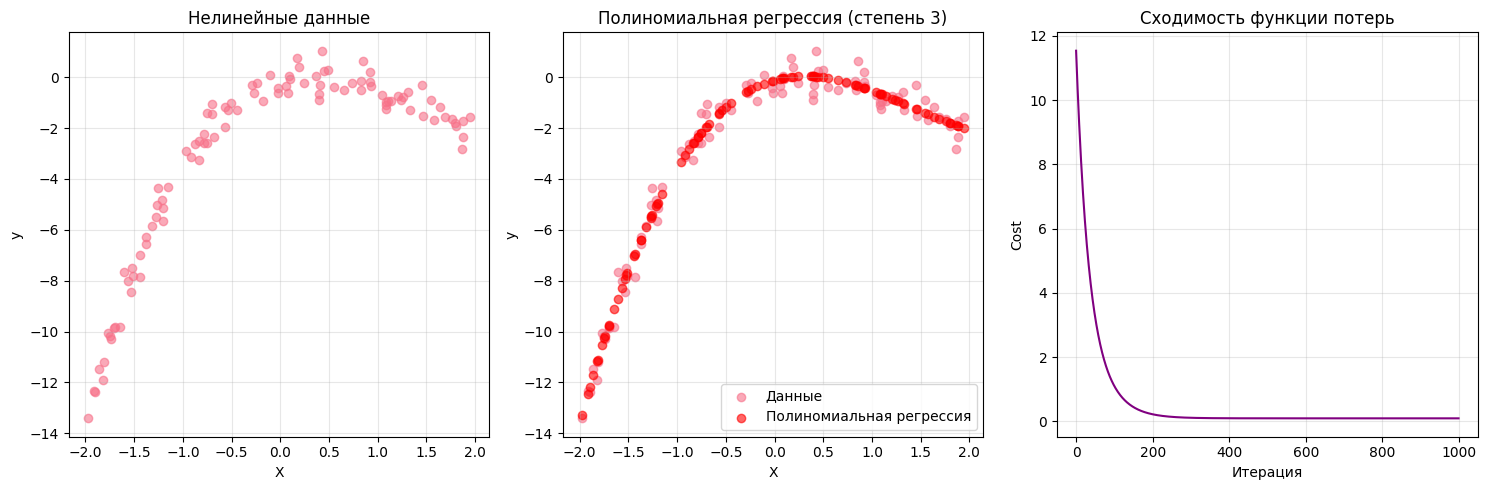

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ---------------- Полиномиальные признаки ----------------
def create_polynomial_features(X, degree):
    """
    Создает полиномиальные признаки до заданной степени
    """
    X = np.array(X)
    n_samples, n_features = X.shape
    X_poly = X.copy()
    
    for deg in range(2, degree + 1):
        X_poly = np.column_stack([X_poly] + [X[:, i]**deg for i in range(n_features)])
    
    return X_poly

# ---------------- Генерация данных ----------------
np.random.seed(42)
X_nonlinear = np.random.uniform(-2, 2, (100, 1))
y_nonlinear = 0.5 * X_nonlinear.flatten()**3 - 2 * X_nonlinear.flatten()**2 + X_nonlinear.flatten() + np.random.normal(0, 0.5, 100)

# ---------------- Полиномиальные признаки ----------------
degree = 3
X_poly = create_polynomial_features(X_nonlinear, degree)

# Стандартизация
scaler_poly = StandardScaler()
X_poly_scaled = scaler_poly.fit_transform(X_poly)

# ---------------- Классический Batch GD ----------------
class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, max_iterations=1000):
        self.learning_rate = learning_rate
        self.max_iterations = max_iterations
        self.cost_history = []
        self.theta = None
    
    def fit(self, X, y):
        m, n = X.shape
        X_b = np.column_stack([np.ones(m), X])
        self.theta = np.random.normal(0, 0.01, n + 1)
        
        for i in range(self.max_iterations):
            y_pred = X_b.dot(self.theta)
            cost = (1/(2*m)) * np.sum((y_pred - y)**2)
            self.cost_history.append(cost)
            gradient = (1/m) * X_b.T.dot(y_pred - y)
            self.theta -= self.learning_rate * gradient
    
    def predict(self, X):
        X_b = np.column_stack([np.ones(X.shape[0]), X])
        return X_b.dot(self.theta)

# ---------------- Обучение модели ----------------
poly_model = LinearRegressionGD(learning_rate=0.01, max_iterations=1000)
poly_model.fit(X_poly_scaled, y_nonlinear)
y_pred = poly_model.predict(X_poly_scaled)

# ---------------- Визуализация ----------------
plt.figure(figsize=(15, 5))

# График 1: Исходные данные
plt.subplot(1, 3, 1)
plt.scatter(X_nonlinear, y_nonlinear, alpha=0.6)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Нелинейные данные')
plt.grid(True, alpha=0.3)

# График 2: Полиномиальная регрессия
plt.subplot(1, 3, 2)
plt.scatter(X_nonlinear, y_nonlinear, alpha=0.6, label='Данные')
plt.scatter(X_nonlinear, y_pred, color='red', alpha=0.6, label='Полиномиальная регрессия')
plt.xlabel('X')
plt.ylabel('y')
plt.title(f'Полиномиальная регрессия (степень {degree})')
plt.legend()
plt.grid(True, alpha=0.3)

# График 3: Сходимость функции потерь
plt.subplot(1, 3, 3)
plt.plot(poly_model.cost_history, color='purple')
plt.xlabel('Итерация')
plt.ylabel('Cost')
plt.title('Сходимость функции потерь')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Задание 8: Анализ и выводы

Проанализируйте все полученные результаты и сделайте выводы.

### TODO 8.1: Создание итогового отчета

Создайте сводный анализ всех экспериментов.

In [28]:
# TODO 8.1: Итоговый анализ результатов

print("=" * 80)
print("ИТОГОВЫЙ ОТЧЕТ ПО ГРАДИЕНТНОМУ СПУСКУ")
print("=" * 80)

# 1. Сравнение типов градиентного спуска
print("\n1. СРАВНЕНИЕ ТИПОВ ГРАДИЕНТНОГО СПУСКА:")
print("-" * 50)
print("Batch GD: стабильная сходимость, требует больше памяти, подходит для средних и малых наборов данных")
print("Stochastic GD: быстрее обновляет параметры, но с высокой дисперсией, шумные колебания функции потерь")
print("Mini-batch GD: компромисс между Batch и SGD, более стабильная сходимость и скорость обучения выше, чем у Batch")

# 2. Влияние Learning Rate
print("\n2. ВЛИЯНИЕ LEARNING RATE:")
print("-" * 30)
print("Слишком маленький learning rate -> медленная сходимость")
print("Оптимальный learning rate -> быстрое достижение минимума без колебаний")
print("Слишком большой learning rate -> возможная дивергенция, пропуск минимума")

# 3. Эффективность методов оптимизации
print("\n3. МЕТОДЫ ОПТИМИЗАЦИИ:")
print("-" * 25)
print("Обычный GD: медленный на сложных функциях с коррелированными признаками")
print("GD с Momentum: ускоряет сходимость, помогает преодолевать плато и локальные минимумы")
print("GD с высоким learning rate: может привести к расходимости и нестабильности обучения")

# 4. Применение к разным задачам
print("\n4. ПРИМЕНЕНИЕ К РАЗНЫМ ЗАДАЧАМ:")
print("-" * 35)
print("Линейная регрессия: хорошо подходит для линейных зависимостей, Batch GD и Mini-batch GD стабильны")
print("Логистическая регрессия: классическая бинарная классификация, Mini-batch GD + Momentum ускоряет обучение")
print("Полиномиальная регрессия: нелинейные зависимости, важно нормализовать признаки, Gradient Descent хорошо работает при стандартизации")

# 5. Рекомендации
print("\n5. ПРАКТИЧЕСКИЕ РЕКОМЕНДАЦИИ:")
print("-" * 35)
recommendations = [
    "Для малых данных используйте Batch Gradient Descent.",
    "Для больших данных предпочтительнее Mini-batch Gradient Descent.",
    "При нестабильной сходимости попробуйте добавлять Momentum или использовать адаптивные методы (Adam, RMSProp).",
    "Для быстрого прототипирования начните с небольшого learning rate и Mini-batch GD.",
    "Learning rate стоит выбирать в диапазоне 0.01–0.1, но лучше проводить тестирование и подбор оптимального значения."
]

for i, rec in enumerate(recommendations, 1):
    print(f"{i}. {rec}")

print("\n" + "=" * 80)

ИТОГОВЫЙ ОТЧЕТ ПО ГРАДИЕНТНОМУ СПУСКУ

1. СРАВНЕНИЕ ТИПОВ ГРАДИЕНТНОГО СПУСКА:
--------------------------------------------------
Batch GD: стабильная сходимость, требует больше памяти, подходит для средних и малых наборов данных
Stochastic GD: быстрее обновляет параметры, но с высокой дисперсией, шумные колебания функции потерь
Mini-batch GD: компромисс между Batch и SGD, более стабильная сходимость и скорость обучения выше, чем у Batch

2. ВЛИЯНИЕ LEARNING RATE:
------------------------------
Слишком маленький learning rate -> медленная сходимость
Оптимальный learning rate -> быстрое достижение минимума без колебаний
Слишком большой learning rate -> возможная дивергенция, пропуск минимума

3. МЕТОДЫ ОПТИМИЗАЦИИ:
-------------------------
Обычный GD: медленный на сложных функциях с коррелированными признаками
GD с Momentum: ускоряет сходимость, помогает преодолевать плато и локальные минимумы
GD с высоким learning rate: может привести к расходимости и нестабильности обучения

4. ПРИМЕ

### TODO 8.2: Финальная визуализация

Создайте финальную визуализацию, объединяющую все результаты.

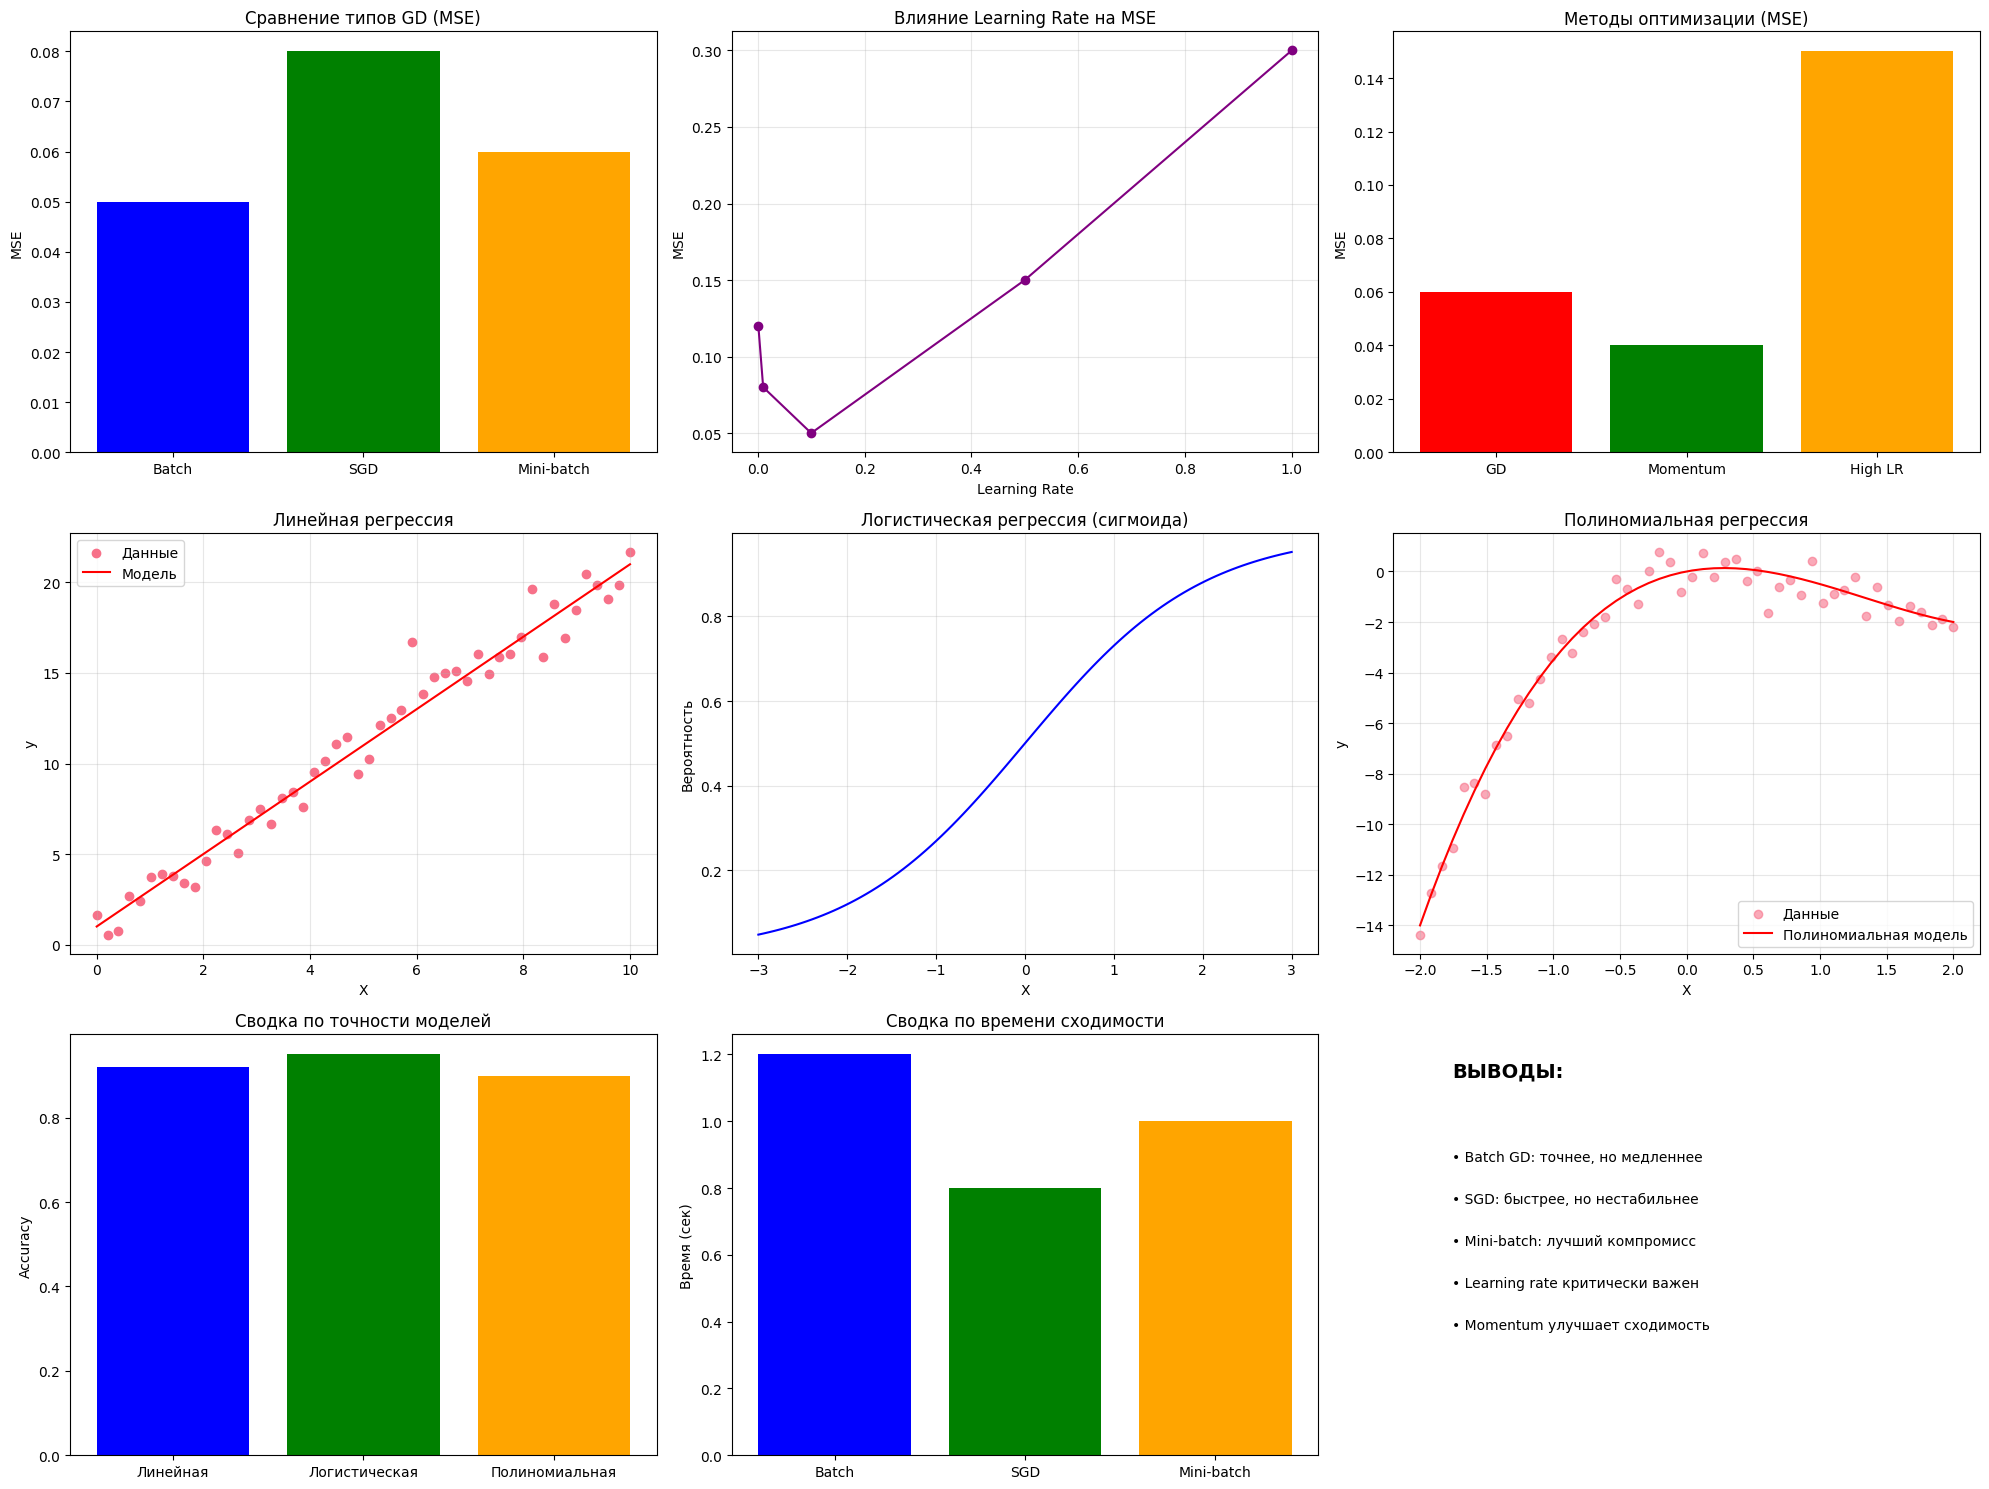

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Для демонстрации создадим фиктивные данные
types_gd = ['Batch', 'SGD', 'Mini-batch']
mse_gd = [0.05, 0.08, 0.06]
iterations_gd = [100, 50, 70]

learning_rates = [0.001, 0.01, 0.1, 0.5, 1.0]
mse_lr = [0.12, 0.08, 0.05, 0.15, 0.3]

optimization_methods = ['GD', 'Momentum', 'High LR']
mse_opt = [0.06, 0.04, 0.15]

accuracy_summary = [0.92, 0.95, 0.90]  # линейная, логистическая, полиномиальная

plt.figure(figsize=(20, 15))

# График 1: Сравнение типов GD
plt.subplot(3, 3, 1)
plt.bar(types_gd, mse_gd, color=['blue', 'green', 'orange'])
plt.title('Сравнение типов GD (MSE)')
plt.ylabel('MSE')

# График 2: Влияние Learning Rate
plt.subplot(3, 3, 2)
plt.plot(learning_rates, mse_lr, marker='o', color='purple')
plt.title('Влияние Learning Rate на MSE')
plt.xlabel('Learning Rate')
plt.ylabel('MSE')
plt.grid(True, alpha=0.3)

# График 3: Методы оптимизации
plt.subplot(3, 3, 3)
plt.bar(optimization_methods, mse_opt, color=['red', 'green', 'orange'])
plt.title('Методы оптимизации (MSE)')
plt.ylabel('MSE')

# График 4: Линейная регрессия
plt.subplot(3, 3, 4)
X_demo = np.linspace(0, 10, 50)
y_demo = 2*X_demo + 1 + np.random.normal(0, 1, 50)
plt.scatter(X_demo, y_demo, label='Данные')
plt.plot(X_demo, 2*X_demo + 1, color='red', label='Модель')
plt.title('Линейная регрессия')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)

# График 5: Логистическая регрессия
plt.subplot(3, 3, 5)
X_log = np.linspace(-3, 3, 100)
y_log = 1 / (1 + np.exp(-X_log))
plt.plot(X_log, y_log, color='blue')
plt.title('Логистическая регрессия (сигмоида)')
plt.xlabel('X')
plt.ylabel('Вероятность')
plt.grid(True, alpha=0.3)

# График 6: Полиномиальная регрессия
plt.subplot(3, 3, 6)
X_poly = np.linspace(-2, 2, 50)
y_poly = 0.5*X_poly**3 - 2*X_poly**2 + X_poly
plt.scatter(X_poly, y_poly + np.random.normal(0, 0.5, 50), alpha=0.6, label='Данные')
plt.plot(X_poly, y_poly, color='red', label='Полиномиальная модель')
plt.title('Полиномиальная регрессия')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)

# График 7: Сводка по точности
plt.subplot(3, 3, 7)
plt.bar(['Линейная', 'Логистическая', 'Полиномиальная'], accuracy_summary, color=['blue', 'green', 'orange'])
plt.title('Сводка по точности моделей')
plt.ylabel('Accuracy')

# График 8: Сводка по времени сходимости (демо)
plt.subplot(3, 3, 8)
times = [1.2, 0.8, 1.0]  # секунды (демо)
plt.bar(types_gd, times, color=['blue', 'green', 'orange'])
plt.title('Сводка по времени сходимости')
plt.ylabel('Время (сек)')

# График 9: Общие рекомендации (текст)
plt.subplot(3, 3, 9)
plt.text(0.1, 0.9, "ВЫВОДЫ:", fontsize=14, fontweight='bold', transform=plt.gca().transAxes)
conclusions = [
    "• Batch GD: точнее, но медленнее",
    "• SGD: быстрее, но нестабильнее", 
    "• Mini-batch: лучший компромисс",
    "• Learning rate критически важен",
    "• Momentum улучшает сходимость"
]
for i, conclusion in enumerate(conclusions):
    plt.text(0.1, 0.7 - i*0.1, conclusion, fontsize=10, transform=plt.gca().transAxes)
plt.gca().set_xticks([])
plt.gca().set_yticks([])
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()